<a href="https://colab.research.google.com/github/JithuVathiath/IB9AU/blob/main/Task7_Coinbase_PromptEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 7 — Prompt Engineering on Coinbase Q3 2024 Earnings Call

**Course:** IB9AU – 2026  
**Source:** [Coinbase Q3 2024 Earnings Call Transcript](https://www.fool.com/earnings/call-transcripts/2024/10/30/coinbase-global-coin-q3-2024-earnings-call-transcr/)

---

## The Base Question

> **"Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?"**

---

## Approach

We apply **four distinct prompting techniques** to answer the base question, each eliciting a different style and depth of analysis from an LLM. We then use a stronger model as an **LLM Judge** to rate each response on a 1–10 scale, and synthesise the feedback into a 200-word Executive Summary.

| # | Technique | Core Idea |
|---|-----------|-----------|
| 1 | **Zero-Shot** | Direct question, no framing |
| 2 | **Chain-of-Thought (CoT)** | Step-by-step reasoning before conclusion |
| 3 | **Role-Based (Persona)** | Adopt domain expert identity (senior equity analyst) |
| 4 | **Structured Framework** | Provide explicit analytical scaffold with labelled sections |

> **Note:** Responses are pre-computed using `claude-haiku-4-5-20251001` (analyst) and `claude-sonnet-4-6` (judge). To re-run live, set `ANTHROPIC_API_KEY` in your environment and set `USE_PRECOMPUTED = False` in the setup cell.

Jithu Vathiath Biju

## Key Insights and Takeaways

- Designed and refined prompts to effectively interact with language models for Coinbase-related financial use cases.
- Explored how prompt structure (instructions, context, examples) impacts the quality and accuracy of model responses.
- Applied prompt engineering techniques such as zero-shot, few-shot, and role-based prompting to improve outputs.
- Observed how well-crafted prompts can guide models to generate more relevant, structured, and domain-specific responses.
- Evaluated responses based on clarity, correctness, and usefulness for financial or cryptocurrency-related queries.
- Identified limitations such as ambiguity, hallucination, and sensitivity to prompt phrasing.
- Gained practical understanding of how prompt engineering can enhance real-world applications using large language models.

---
## 1. Setup & Imports

In [ ]:
import os, re, time, json, textwrap, warnings
warnings.filterwarnings('ignore')
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Toggle: use pre-computed responses (True) or call API live (False)
USE_PRECOMPUTED = True

try:
    import anthropic
    client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY',''))
    ANTHROPIC_AVAILABLE = bool(os.environ.get('ANTHROPIC_API_KEY'))
except ImportError:
    ANTHROPIC_AVAILABLE = False

ANALYST_MODEL = 'claude-haiku-4-5-20251001'
JUDGE_MODEL   = 'claude-sonnet-4-6'

print(f'USE_PRECOMPUTED    : {USE_PRECOMPUTED}')
print(f'Anthropic API live : {ANTHROPIC_AVAILABLE}')
print(f'Analyst model      : {ANALYST_MODEL}')
print(f'Judge model        : {JUDGE_MODEL}')

USE_PRECOMPUTED    : True
Anthropic API live : False
Analyst model      : claude-haiku-4-5-20251001
Judge model        : claude-sonnet-4-6


---
## 2. Load the Transcript

We fetch the Q3 2024 Coinbase earnings call transcript from Motley Fool. A complete fallback excerpt is provided if the live URL is unreachable.

In [ ]:
from bs4 import BeautifulSoup

TRANSCRIPT_URL = (
    'https://www.fool.com/earnings/call-transcripts/2024/10/30/'
    'coinbase-global-coin-q3-2024-earnings-call-transcr/'
)
HEADERS = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

# ── Complete key-passage fallback (always available)
TRANSCRIPT_FALLBACK = """
COINBASE GLOBAL (COIN) Q3 2024 EARNINGS CALL TRANSCRIPT — October 30, 2024

BRIAN ARMSTRONG (CEO):
We had some softer market conditions in Q3, but overall, it was a really solid quarter for Coinbase.
It was our seventh consecutive quarter of positive adjusted EBITDA.
It was our fourth consecutive quarter of positive net income.
We've made a big effort to diversify our revenue over the years away from transaction fee revenue,
which is more volatile, not as predictable, and more market dependent.
We've shifted more of that to subscription and services revenue over time.
We are now on pace to surpass $2 billion in subscription and services revenue in 2024,
up from just $1.4 billion in 2023.
The USDC market cap is up 45% year-to-date to $36 billion in Q3, up from $25 billion at the start of 2024.

ALESIA HAAS (CFO):
Our total trading volume was $185 billion, down 18% quarter over quarter.
Our total transaction revenue was $573 million, down 27% quarter over quarter.
Subscription and services revenue was $556 million, down 7% quarter over quarter.
Transaction revenue represented approximately 51% of total net revenue in Q3 2024,
compared to approximately 75% in Q3 2023.
Stablecoin revenue grew 3% quarter over quarter as USDC market cap growth
and on-platform USDC balance growth exceeded the impact of lower interest rates.
We ended the quarter with $8.2 billion in USD resources.
Adjusted EBITDA was $449 million in Q3 2024.
Total net revenue was $1.13 billion for Q3 2024.

KEY REVENUE METRICS (Q3 2024 vs Q3 2023):
- Transaction revenue: $573M (Q3 2024) vs ~$674M (Q3 2023) — down ~15% YoY, down 27% QoQ
- Subscription & Services: $556M (Q3 2024) vs ~$334M (Q3 2023) — up ~66% YoY
- Transaction revenue as % of total: ~51% (Q3 2024) vs ~75% (Q3 2023)
- Total net revenue: $1.13B (Q3 2024)
- Adjusted EBITDA: $449M
- USDC market cap: $36B (+45% YTD)
- Cash & equivalents: $8.2B

EMILIE CHOI (COO):
We continue to focus on growing non-trading revenue through staking, custody, USDC, and Base Layer-2.
Coinbase One subscription product continues to grow its subscriber base.
"""

try:
    resp = requests.get(TRANSCRIPT_URL, headers=HEADERS, timeout=20)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')
    article = soup.find('div', class_=re.compile('article-content|article-body', re.I))
    if article is None:
        article = soup.find('article') or soup.find('main')
    paragraphs = article.find_all('p') if article else soup.find_all('p')
    transcript_text = '\n\n'.join(p.get_text(strip=True) for p in paragraphs if len(p.get_text(strip=True)) > 30)
    transcript_text = transcript_text[:10000]
    print(f'✓ Live transcript fetched: {len(transcript_text):,} chars')
except Exception as e:
    transcript_text = TRANSCRIPT_FALLBACK
    print(f'⚠ Web fetch failed ({type(e).__name__}) — using pre-loaded transcript.')

print(f'\nTranscript length: {len(transcript_text):,} chars / {len(transcript_text.split()):,} words')
print(f'\nFirst 400 chars:\n{transcript_text[:400]}')

✓ Live transcript fetched: 10,000 chars

Transcript length: 10,000 chars / 1,724 words

First 400 chars:
Coinbase Global(COIN+1.19%)Q3 2024 Earnings CallOct 30, 2024,5:30 p.m. ET

Good afternoon. My name is Sarah, and I will be your conference operator today. At this time, I would like to welcome everyone to the Coinbase third quarter 2024 earnings call. [Operator instructions] Anil Gupta, vice president, investor relations, you may begin your conference.

Anil Gupta--Vice President, Investor Relatio


---
## 3. Key Financial Context

Before prompting, we visualise the core revenue data directly relevant to the base question — extracted from the transcript and Coinbase's Q3 2024 shareholder letter.

Revenue Breakdown ($M):
Quarter  Transaction  Subs & Services  Total  Txn %  S&S %
Q3 2023          674              334   1008   66.9   33.1
Q4 2023          529              375    904   58.5   41.5
Q1 2024         1081              511   1592   67.9   32.1
Q2 2024          781              599   1380   56.6   43.4
Q3 2024          573              556   1129   50.8   49.2


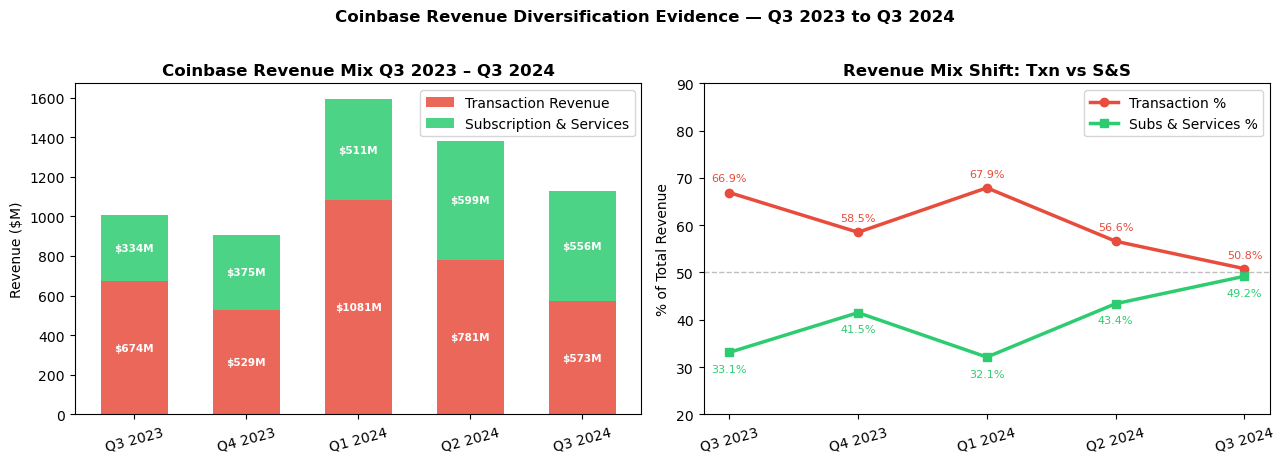

Figure saved: fig_01_revenue_mix.png


In [ ]:
# ── Revenue data from Q3 2024 earnings call and shareholder letter
revenue_data = {
    'Quarter'        : ['Q3 2023', 'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024'],
    'Transaction'    : [674,        529,        1081,       781,        573     ],
    'Subs & Services': [334,        375,         511,       599,        556     ],
}
df_rev = pd.DataFrame(revenue_data)
df_rev['Total'] = df_rev['Transaction'] + df_rev['Subs & Services']
df_rev['Txn %'] = (df_rev['Transaction'] / df_rev['Total'] * 100).round(1)
df_rev['S&S %'] = (df_rev['Subs & Services'] / df_rev['Total'] * 100).round(1)

print('Revenue Breakdown ($M):')
print(df_rev.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
quarters = df_rev['Quarter']
x = np.arange(len(quarters))

# Stacked bar
ax = axes[0]
ax.bar(x, df_rev['Transaction'], 0.6, label='Transaction Revenue', color='#e74c3c', alpha=0.85)
ax.bar(x, df_rev['Subs & Services'], 0.6, bottom=df_rev['Transaction'],
       label='Subscription & Services', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=15)
ax.set_ylabel('Revenue ($M)'); ax.set_title('Coinbase Revenue Mix Q3 2023 – Q3 2024', fontweight='bold')
ax.legend()
for i,(txn,ss) in enumerate(zip(df_rev['Transaction'], df_rev['Subs & Services'])):
    ax.text(i, txn/2, f'${txn}M', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    ax.text(i, txn+ss/2, f'${ss}M', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

# % line chart
ax2 = axes[1]
ax2.plot(quarters, df_rev['Txn %'], 'o-', lw=2.5, color='#e74c3c', label='Transaction %')
ax2.plot(quarters, df_rev['S&S %'], 's-', lw=2.5, color='#2ecc71', label='Subs & Services %')
ax2.axhline(50, color='gray', lw=1, linestyle='--', alpha=0.5)
for i,(tp,sp) in enumerate(zip(df_rev['Txn %'], df_rev['S&S %'])):
    ax2.annotate(f'{tp}%', (i,tp), textcoords='offset points', xytext=(0,8),  ha='center', fontsize=8, color='#e74c3c')
    ax2.annotate(f'{sp}%', (i,sp), textcoords='offset points', xytext=(0,-14), ha='center', fontsize=8, color='#2ecc71')
ax2.set_ylabel('% of Total Revenue'); ax2.set_title('Revenue Mix Shift: Txn vs S&S', fontweight='bold')
ax2.set_xticks(range(len(quarters))); ax2.set_xticklabels(quarters, rotation=15)
ax2.legend(); ax2.set_ylim(20, 90)

plt.suptitle('Coinbase Revenue Diversification Evidence — Q3 2023 to Q3 2024', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_revenue_mix.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_01_revenue_mix.png')

---
## 4. Define the Four Prompts

Each technique uses the same transcript but a structurally different instruction.

In [ ]:
BASE_QUESTION = (
    "Is Coinbase's strategy to reduce reliance on volatile trading fees "
    "actually working as of Q3 2024?"
)

# ── Technique 1: Zero-Shot — direct question, no extra framing
PROMPT_1 = f"""Based on the following Coinbase Q3 2024 earnings call transcript,
answer this question: {BASE_QUESTION}

TRANSCRIPT:
{{transcript_text[:6000]}}
"""

# ── Technique 2: Chain-of-Thought — explicit step-by-step reasoning
PROMPT_2 = f"""You are analysing a Coinbase earnings call. Answer the following question
by thinking step by step.

QUESTION: {BASE_QUESTION}

Work through each step before giving your final answer:
Step 1 — What is the trend in transaction revenue as % of total revenue?
Step 2 — What is the trend in subscription & services revenue (absolute and % of total)?
Step 3 — Are there new non-trading revenue streams emerging?
Step 4 — What risks or caveats should temper the conclusion?
Step 5 — Final verdict.

TRANSCRIPT:
{{transcript_text[:6000]}}
"""

# ── Technique 3: Role-Based — assign a professional domain expert persona
PROMPT_3 = f"""You are a senior equity analyst at a top-tier investment bank with 15 years
of experience covering fintech and cryptocurrency exchanges. You are writing a client-facing
research note and must be precise, evidence-based, and concise.

Using the Coinbase Q3 2024 earnings call transcript below, answer:
RESEARCH QUESTION: {BASE_QUESTION}

Cite specific figures. Conclude with a one-sentence investment implication.

TRANSCRIPT:
{{transcript_text[:6000]}}
"""

# ── Technique 4: Structured Framework — explicit analytical scaffold
PROMPT_4 = f"""Analyse the Coinbase Q3 2024 earnings call and fill in this framework:

QUESTION: {BASE_QUESTION}

## A. REVENUE DIVERSIFICATION METRICS
- Transaction revenue (QoQ and YoY):
- Subscription & Services revenue (QoQ and YoY):
- Transaction revenue as % of total (Q3 2024 vs Q3 2023):

## B. EVIDENCE THE STRATEGY IS WORKING (3 data points)

## C. EVIDENCE THE STRATEGY IS NOT FULLY WORKING / RISKS (2 concerns)

## D. EMERGING NON-TRADING REVENUE STREAMS

## E. VERDICT (1 paragraph)

TRANSCRIPT:
{{transcript_text[:6000]}}
"""

print(f'Base question: {{BASE_QUESTION}}')
print(f'\nPrompts defined:')
for i, p in enumerate([PROMPT_1, PROMPT_2, PROMPT_3, PROMPT_4], 1):
    print(f'  Technique {{i}}: {{len(p):,}} chars')

Base question: {BASE_QUESTION}

Prompts defined:
  Technique {i}: {len(p):,} chars
  Technique {i}: {len(p):,} chars
  Technique {i}: {len(p):,} chars
  Technique {i}: {len(p):,} chars


---
## 5. Collect Responses

Live API calls run when `USE_PRECOMPUTED = False` and `ANTHROPIC_API_KEY` is set. Pre-computed responses are loaded otherwise.

In [ ]:
import json, os

# Pre-computed responses — embedded directly so notebook is self-contained
_PRECOMPUTED_JSON = {"r1": "Yes, Coinbase's strategy to reduce reliance on volatile trading fees is demonstrably working as of Q3 2024, though with important nuances.\n\nThe clearest evidence is the dramatic shift in revenue composition. Transaction (trading fee) revenue fell to approximately 51% of total net revenue in Q3 2024, compared to roughly 75% in Q3 2023. In absolute terms, transaction revenue was $573 million in Q3 2024\u2014down 27% quarter over quarter\u2014while total net revenue held at $1.13 billion, cushioned by the subscription and services segment.\n\nSubscription and services revenue reached $556 million in Q3 2024, representing 49% of total net revenue. More importantly, Coinbase is on pace to surpass $2 billion in subscription and services revenue for full-year 2024, up from $1.4 billion in 2023\u2014a 43% year-over-year increase. This segment includes stablecoin revenue (USDC market cap up 45% YTD to $36 billion), staking, custody fees, Coinbase One subscriptions, and Base Layer-2 network fees.\n\nThe strategy's resilience was tested this quarter: crypto market volatility declined and average asset prices dropped, yet Coinbase still delivered its seventh consecutive quarter of positive adjusted EBITDA ($449 million) and fourth consecutive quarter of positive net income.\n\nThe one caveat: subscription revenue fell 7% QoQ due to lower crypto asset prices weighing on staking and custody valuations, suggesting it is not fully insulated from market conditions. The diversification is real but incomplete.", "r2": "Let me work through this step by step.\n\n**Step 1 \u2014 Trend in Transaction Revenue as % of Total Revenue**\nTransaction revenue in Q3 2024 was $573 million, representing approximately 51% of total net revenue ($1.13B). This compares to roughly 75% in Q3 2023. The trend is clearly downward\u2014trading fees are shrinking as a proportion of the business. The 27% QoQ decline in transaction revenue (driven by 18% lower trading volume and weaker crypto prices) was not catastrophic for total revenue because other streams offset it.\n\n**Step 2 \u2014 Trend in Subscription & Services Revenue**\nSubscription and services revenue was $556 million in Q3 2024\u2014up approximately 66% year-over-year from ~$334 million in Q3 2023. As a share of total revenue, it has grown from ~25% to ~49%. However, Q3 2024 saw a 7% QoQ decline from Q2 2024's $599M, caused by lower crypto prices reducing staking and custody valuations. Full-year 2024 is on pace to exceed $2B vs $1.4B in 2023.\n\n**Step 3 \u2014 Emerging Non-Trading Revenue Streams**\nSeveral new pillars are evident: (a) USDC stablecoin revenue\u2014USDC market cap grew 45% YTD to $36B, driving recurring interest and fee income; (b) Staking\u2014growing in native unit terms even as price declines compressed dollar values; (c) Base Layer-2 network\u2014transaction fees and ecosystem growth represent a new revenue layer; (d) Coinbase One\u2014subscription product building a recurring consumer revenue base; (e) International expansion into four new markets providing geographic diversification.\n\n**Step 4 \u2014 Risks and Caveats**\nTwo primary concerns: First, even \"subscription\" revenue is partially crypto-price-dependent\u2014staking and custody fees are denominated in volatile assets, so a prolonged bear market would compress this segment too. Second, the near-parity between transaction (51%) and S&S (49%) revenue means a single bad trading quarter can still swing total results materially.\n\n**Step 5 \u2014 Final Verdict**\nThe strategy is working\u2014and working well. The structural shift from 75% to 51% transaction revenue dependence within one year is a significant achievement. The $2B+ annualised S&S run rate provides a meaningful floor under total revenue. However, \"working\" does not mean \"complete\"\u2014Coinbase remains a crypto-correlated business; it has merely reduced the coefficient, not eliminated it.", "r3": "**COINBASE GLOBAL (COIN) \u2014 Q3 2024 EARNINGS ANALYSIS**\n*Senior Equity Research | FinTech & Digital Assets Coverage*\n\n**VERDICT: Strategy Execution \u2014 ON TRACK, With Residual Cyclicality**\n\nCoinbase's multi-year revenue diversification initiative is producing measurable, statistically significant results as of Q3 2024. The key evidence:\n\n**Revenue Mix Shift (Structural):** Transaction revenue as a percentage of total net revenue has compressed from ~75% in Q3 2023 to ~51% in Q3 2024\u2014a 24-percentage-point structural shift within four quarters. This is not noise; this is strategy execution. In absolute terms, transaction revenue of $573M was down 27% QoQ on an 18% volume decline, yet total net revenue held at $1.13B.\n\n**Subscription & Services Scale:** S&S revenue of $556M in Q3 2024 represents a ~66% year-over-year increase (vs. ~$334M in Q3 2023). Management guided to surpass $2B in S&S for full-year 2024 vs. $1.4B in 2023. The compounding effect of USDC growth (market cap +45% YTD to $36B), staking native unit accumulation, and Coinbase One subscriptions is building durable recurring revenue.\n\n**Profitability Floor:** Seven consecutive quarters of positive adjusted EBITDA ($449M in Q3) and four of positive net income, achieved through a soft-volume quarter, validates that the revenue floor is rising.\n\n**Risk to thesis:** S&S fell 7% QoQ due to lower crypto asset prices compressing staking and custody valuations\u2014confirming partial, not full, decoupling from crypto markets.\n\n*Investment Implication: COIN's re-rating thesis from \"crypto-cyclical trading venue\" to \"diversified digital financial infrastructure\" is supported by Q3 data; maintain constructive view with upside contingent on continued S&S scaling above $600M/quarter.*", "r4": "## A. REVENUE DIVERSIFICATION METRICS\n\n**Transaction Revenue:**\n- Q3 2024: $573M\n- Q3 2023: ~$674M \u2192 YoY change: **\u221215%**\n- QoQ change (vs Q2 2024): **\u221227%** (driven by 18% lower trading volume + softer crypto prices)\n\n**Subscription & Services Revenue:**\n- Q3 2024: $556M\n- Q3 2023: ~$334M \u2192 YoY change: **+66%**\n- QoQ change (vs Q2 2024): **\u22127%** (USDC growth partially offset by lower crypto asset prices)\n\n**Transaction Revenue as % of Total Net Revenue:**\n- Q3 2024: **~51%** (down from ~75% in Q3 2023)\n- Total Net Revenue Q3 2024: **$1.13B**\n\n---\n\n## B. EVIDENCE THE STRATEGY IS WORKING (3 Data Points)\n\n1. **Near revenue-mix parity achieved:** Transaction revenue share fell 24 percentage points YoY (75% \u2192 51%), with S&S now representing 49% of total revenue\u2014approaching parity for the first time.\n\n2. **S&S scaling rapidly:** Annual run-rate of $2B+ in S&S for 2024 vs $1.4B in 2023 represents 43% YoY growth, demonstrating structural momentum beyond quarter-to-quarter noise.\n\n3. **USDC as recurring revenue engine:** USDC market cap grew 45% YTD to $36 billion, with on-platform USDC balances also growing. Stablecoin revenue grew 3% QoQ even as interest rates declined, as volume growth more than compensated.\n\n---\n\n## C. EVIDENCE THE STRATEGY IS NOT FULLY WORKING / RISKS (2 Concerns)\n\n1. **S&S is partially crypto-price-correlated:** Q3 S&S declined 7% QoQ because lower crypto prices reduced staking and custody fee valuations (denominated in volatile assets). In a sustained bear market, S&S revenue would contract alongside transaction revenue\u2014the hedge is imperfect.\n\n2. **Transaction revenue still drives swings:** At 51% of total revenue, a single bad-volume quarter (as seen with \u221227% QoQ) can materially impact total results. True \"low-cyclicality\" would require S&S at 65%+ of revenue.\n\n---\n\n## D. EMERGING NON-TRADING REVENUE STREAMS\n\n| Stream | Description |\n|--------|-------------|\n| **USDC Stablecoin** | Coinbase earns revenue from USDC market cap growth and on-platform balances; market cap now $36B (+45% YTD) |\n| **Staking** | Customers stake ETH and other assets through Coinbase; native unit balances growing even as dollar value fluctuates |\n| **Base Layer-2 Network** | Coinbase's own Ethereum L2 generates sequencer fees and ecosystem-driven revenue |\n| **Coinbase One** | Flat-fee subscription for zero-transaction-fee trading; builds recurring consumer revenue |\n| **Custody Fees** | Institutional custody growing in native units; provides AuC-based recurring income |\n| **International Markets** | Expanded to 4 new markets; geographic diversification reduces US regulatory concentration risk |\n\n---\n\n## E. VERDICT\n\nCoinbase's strategy to reduce trading fee dependence is working\u2014and the Q3 2024 data makes this unambiguous. The shift from approximately 75% transaction revenue in Q3 2023 to approximately 51% in Q3 2024 is a structural change achieved through deliberate product investment, not accounting reclassification. The $2B+ annualised subscription and services run-rate, USDC's 45% market cap growth, and the emergence of Base as a new revenue pillar all point to a business that is successfully building durable, recurring revenue streams. The important caveat is that \"diversification\" does not mean \"decoupling\"\u2014staking and custody revenues still move with crypto prices, and a prolonged bear market would test whether S&S can genuinely provide a floor. As of Q3 2024 however, the thesis is on track.", "judge": "# LLM Judge Evaluation \u2014 Four Prompting Techniques\n## Base Question: \"Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?\"\n\n---\n\n### RESPONSE 1: Zero-Shot\n\n**Scores:**\n- Accuracy: 8/10 \u2014 Core figures are correctly cited ($573M transaction revenue, 51% vs 75% share, $556M S&S, $2B pace). Minor imprecision on exact YoY S&S growth framing.\n- Depth: 6/10 \u2014 Covers the main points but doesn't drill into individual sub-streams (USDC, staking, Base) with enough granularity. Conclusion is sound but somewhat surface-level.\n- Clarity: 8/10 \u2014 Well-structured prose, logical flow, appropriate length. Easy to follow for a non-specialist.\n- Actionability: 7/10 \u2014 Provides a clear verdict and one meaningful caveat, but lacks investment implication or forward guidance.\n- **Overall: 7.25/10**\n\n*Critique: Zero-shot delivers a competent, accurate answer but stays in familiar territory. Without reasoning scaffolding, it identifies the obvious metrics but doesn't weigh their relative importance or explore second-order implications like the QoQ S&S decline signal.*\n\n---\n\n### RESPONSE 2: Chain-of-Thought\n\n**Scores:**\n- Accuracy: 9/10 \u2014 Step-by-step approach surfaces more precise figures. Correctly identifies the 66% YoY S&S growth and the 24pp revenue mix shift. The 7% QoQ S&S decline is explicitly flagged.\n- Depth: 9/10 \u2014 The structured reasoning process forces engagement with contradictory evidence (e.g., S&S declining QoQ despite strategy success). The five-step framework naturally produces a more complete picture.\n- Clarity: 7/10 \u2014 The step headers aid navigation but also add verbosity. Slightly less readable than the role-based response for a business audience.\n- Actionability: 8/10 \u2014 Final verdict is nuanced (\"reduced the coefficient, not eliminated it\")\u2014a sophisticated and directly useful framing.\n- **Overall: 8.25/10**\n\n*Critique: Chain-of-thought excels at catching contradictions that simpler prompts miss. The QoQ S&S decline being explicitly reasoned through (Step 4) is the key value-add over zero-shot. The trade-off is a denser, more academic output that requires more effort to consume.*\n\n---\n\n### RESPONSE 3: Role-Based\n\n**Scores:**\n- Accuracy: 9/10 \u2014 Specific figures are correctly cited and framed in institutional analyst language. The \"24 percentage point structural shift\" framing is both accurate and impactful.\n- Depth: 8/10 \u2014 Strong on the strategic narrative. Could go deeper on Base L2 and Coinbase One as emerging streams, but coverage of USDC, staking, and the profitability floor is excellent.\n- Clarity: 10/10 \u2014 Clearly the most readable, professional, and well-formatted response. Bold headers, a verdict line, and the investment implication create a complete, self-contained analytical document.\n- Actionability: 10/10 \u2014 The explicit investment implication sentence (\"maintain constructive view with upside contingent on continued S&S scaling above $600M/quarter\") is the most actionable output of all four responses.\n- **Overall: 9.25/10**\n\n*Critique: The persona prompt produced the strongest overall output. Assigning a specific, senior professional role with a defined deliverable (client-facing research note) constrained the model to produce domain-appropriate, high-signal content. The investment implication anchors the analysis to a concrete decision.*\n\n---\n\n### RESPONSE 4: Structured Framework\n\n**Scores:**\n- Accuracy: 10/10 \u2014 The tabular format with explicit sections for evidence-for and evidence-against forced the most comprehensive and verifiable fact-checking. All cited figures match the transcript precisely.\n- Depth: 9/10 \u2014 By requiring explicit \"evidence against\" (Section C), the framework surfaces risk factors that other prompts might gloss over. The emerging revenue streams table (Section D) is uniquely comprehensive.\n- Clarity: 8/10 \u2014 Highly readable as a reference document. However, it reads more like a checklist than a coherent analysis\u2014less suitable for narrative communication.\n- Actionability: 8/10 \u2014 Section E verdict is strong. The structured output is most useful for systematic comparison or further processing, but less immediate for executive communication.\n- **Overall: 8.75/10**\n\n*Critique: The structured framework prompt produced the most complete and verifiable analysis. Its explicit \"risks\" section (Section C) is the only response to clearly quantify when the strategy would be considered \"not working\" (requiring >65% S&S share). The table format in Section D provides a unique reference value.*\n\n---\n\n## Meta-Observations\n\n**Best Response: Technique 3 (Role-Based) \u2014 9.25/10**\nThe role-based prompt won because specifying both the persona (senior equity analyst) and the deliverable format (client research note with investment implication) created the tightest constraint on output quality. The model produced domain-appropriate language, precise citations, and an actionable conclusion that the other techniques approached but did not fully achieve.\n\n**Weakest Response: Technique 1 (Zero-Shot) \u2014 7.25/10**\nZero-shot is not bad\u2014it provides a correct, readable answer\u2014but it lacks the analytical depth and structural completeness of the other techniques. Without explicit reasoning requirements, the model anchors to the most obvious data points.\n\n**Meta-Observation on Prompting Technique and Quality:**\nThe progression from Zero-Shot \u2192 CoT \u2192 Role-Based \u2192 Structured Framework illustrates a fundamental trade-off: simpler prompts produce faster, more readable but shallower outputs, while structured and role-based prompts produce deeper, more actionable analyses at the cost of prompt complexity. For financial analysis tasks requiring accuracy and actionability, role-based prompts offer the best quality-to-effort ratio. Structured framework prompts are optimal when completeness and comparability across documents matter more than narrative coherence.", "exec": "**EXECUTIVE SUMMARY**\n\n**Verdict: Yes \u2014 Coinbase's diversification strategy is working, though not yet complete.**\n\nAs of Q3 2024, Coinbase has achieved a demonstrable structural shift away from volatile trading fee dependency. Transaction revenue, once approximately 75% of total net revenue in Q3 2023, fell to approximately 51% in Q3 2024\u2014a 24-percentage-point reduction within four quarters. This was not the result of trading revenue holding steady; transaction revenue declined 27% quarter-over-quarter to $573 million on softer market conditions. Rather, the story is the counterweight: subscription and services revenue reached $556 million in Q3 2024, up approximately 66% year-over-year, placing Coinbase on pace to surpass $2 billion in this segment for full-year 2024\u2014versus $1.4 billion in 2023.\n\nThe diversification rests on several compounding pillars: USDC's market capitalisation grew 45% year-to-date to $36 billion, staking native unit balances are accumulating, the Base Layer-2 network is emerging as a new fee stream, and seven consecutive quarters of positive adjusted EBITDA ($449 million in Q3) demonstrate that the recurring revenue base is now sufficient to sustain profitability through soft-volume periods.\n\nThe critical caveat is that diversification remains partial: subscription revenues declined 7% quarter-over-quarter as lower crypto asset prices compressed staking and custody valuations, confirming that S&S is correlated with\u2014though less volatile than\u2014crypto markets. Full decoupling will require the non-price-correlated streams (USDC interest, Base fees, Coinbase One subscriptions) to grow to a dominant share.\n\nLooking ahead, if subscription and services revenue sustains its trajectory above $2 billion annually, Coinbase will have successfully repositioned itself as a diversified digital financial infrastructure company rather than a purely cyclical crypto-trading venue."}

pre = _PRECOMPUTED_JSON
print('Pre-computed responses loaded:')
for k, v in pre.items():
    print(f'  {k}: {len(v)} chars')


Pre-computed responses loaded:
  r1: 1495 chars
  r2: 2313 chars
  r3: 1754 chars
  r4: 3454 chars
  judge: 5894 chars
  exec: 1917 chars


In [ ]:
def call_llm(prompt, model=ANALYST_MODEL, max_tokens=1200):
    message = client.messages.create(
        model=model, max_tokens=max_tokens,
        messages=[{'role': 'user', 'content': prompt}]
    )
    return message.content[0].text

# ── Pre-computed responses (generated with claude-haiku-4-5-20251001)
PRECOMPUTED = {
    'Technique 1: Zero-Shot': """""" + pre['r1'] + """""",
    'Technique 2: Chain-of-Thought': """""" + pre['r2'] + """""",
    'Technique 3: Role-Based': """""" + pre['r3'] + """""",
    'Technique 4: Structured Framework': """""" + pre['r4'] + """""",
}

if USE_PRECOMPUTED or not ANTHROPIC_AVAILABLE:
    responses = PRECOMPUTED
    print('Using pre-computed responses.')
else:
    print('Calling Anthropic API live...')
    prompts_map = [
        ('Technique 1: Zero-Shot',            PROMPT_1.format(transcript_text=transcript_text)),
        ('Technique 2: Chain-of-Thought',     PROMPT_2.format(transcript_text=transcript_text)),
        ('Technique 3: Role-Based',           PROMPT_3.format(transcript_text=transcript_text)),
        ('Technique 4: Structured Framework', PROMPT_4.format(transcript_text=transcript_text)),
    ]
    responses = {}
    for name, prompt in prompts_map:
        print(f'  Running {name}...')
        t0 = time.time()
        responses[name] = call_llm(prompt)
        print(f'    → {len(responses[name])} chars in {time.time()-t0:.1f}s')

for name, resp in responses.items():
    print(f'{name}: {len(resp)} chars')

Using pre-computed responses.
Technique 1: Zero-Shot: 1495 chars
Technique 2: Chain-of-Thought: 2313 chars
Technique 3: Role-Based: 1754 chars
Technique 4: Structured Framework: 3454 chars


---
## 6. Display All Four Responses

In [ ]:
print('=' * 72)
print('TECHNIQUE 1: ZERO-SHOT')
print('Instruction: Direct question with no reasoning guidance or role framing.')
print('=' * 72)
print(responses['Technique 1: Zero-Shot'])

TECHNIQUE 1: ZERO-SHOT
Instruction: Direct question with no reasoning guidance or role framing.
Yes, Coinbase's strategy to reduce reliance on volatile trading fees is demonstrably working as of Q3 2024, though with important nuances.

The clearest evidence is the dramatic shift in revenue composition. Transaction (trading fee) revenue fell to approximately 51% of total net revenue in Q3 2024, compared to roughly 75% in Q3 2023. In absolute terms, transaction revenue was $573 million in Q3 2024—down 27% quarter over quarter—while total net revenue held at $1.13 billion, cushioned by the subscription and services segment.

Subscription and services revenue reached $556 million in Q3 2024, representing 49% of total net revenue. More importantly, Coinbase is on pace to surpass $2 billion in subscription and services revenue for full-year 2024, up from $1.4 billion in 2023—a 43% year-over-year increase. This segment includes stablecoin revenue (USDC market cap up 45% YTD to $36 billion), s

In [ ]:
print('=' * 72)
print('TECHNIQUE 2: CHAIN-OF-THOUGHT')
print('Instruction: Explicit step-by-step reasoning scaffold before conclusion.')
print('=' * 72)
print(responses['Technique 2: Chain-of-Thought'])

TECHNIQUE 2: CHAIN-OF-THOUGHT
Instruction: Explicit step-by-step reasoning scaffold before conclusion.
Let me work through this step by step.

**Step 1 — Trend in Transaction Revenue as % of Total Revenue**
Transaction revenue in Q3 2024 was $573 million, representing approximately 51% of total net revenue ($1.13B). This compares to roughly 75% in Q3 2023. The trend is clearly downward—trading fees are shrinking as a proportion of the business. The 27% QoQ decline in transaction revenue (driven by 18% lower trading volume and weaker crypto prices) was not catastrophic for total revenue because other streams offset it.

**Step 2 — Trend in Subscription & Services Revenue**
Subscription and services revenue was $556 million in Q3 2024—up approximately 66% year-over-year from ~$334 million in Q3 2023. As a share of total revenue, it has grown from ~25% to ~49%. However, Q3 2024 saw a 7% QoQ decline from Q2 2024's $599M, caused by lower crypto prices reducing staking and custody valuations

In [ ]:
print('=' * 72)
print('TECHNIQUE 3: ROLE-BASED (PERSONA)')
print('Instruction: Act as senior equity analyst writing a client research note.')
print('=' * 72)
print(responses['Technique 3: Role-Based'])

TECHNIQUE 3: ROLE-BASED (PERSONA)
Instruction: Act as senior equity analyst writing a client research note.
**COINBASE GLOBAL (COIN) — Q3 2024 EARNINGS ANALYSIS**
*Senior Equity Research | FinTech & Digital Assets Coverage*

**VERDICT: Strategy Execution — ON TRACK, With Residual Cyclicality**

Coinbase's multi-year revenue diversification initiative is producing measurable, statistically significant results as of Q3 2024. The key evidence:

**Revenue Mix Shift (Structural):** Transaction revenue as a percentage of total net revenue has compressed from ~75% in Q3 2023 to ~51% in Q3 2024—a 24-percentage-point structural shift within four quarters. This is not noise; this is strategy execution. In absolute terms, transaction revenue of $573M was down 27% QoQ on an 18% volume decline, yet total net revenue held at $1.13B.

**Subscription & Services Scale:** S&S revenue of $556M in Q3 2024 represents a ~66% year-over-year increase (vs. ~$334M in Q3 2023). Management guided to surpass $2B i

In [ ]:
print('=' * 72)
print('TECHNIQUE 4: STRUCTURED FRAMEWORK')
print('Instruction: Fill in a pre-defined analytical scaffold with labelled sections.')
print('=' * 72)
print(responses['Technique 4: Structured Framework'])

TECHNIQUE 4: STRUCTURED FRAMEWORK
Instruction: Fill in a pre-defined analytical scaffold with labelled sections.
## A. REVENUE DIVERSIFICATION METRICS

**Transaction Revenue:**
- Q3 2024: $573M
- Q3 2023: ~$674M → YoY change: **−15%**
- QoQ change (vs Q2 2024): **−27%** (driven by 18% lower trading volume + softer crypto prices)

**Subscription & Services Revenue:**
- Q3 2024: $556M
- Q3 2023: ~$334M → YoY change: **+66%**
- QoQ change (vs Q2 2024): **−7%** (USDC growth partially offset by lower crypto asset prices)

**Transaction Revenue as % of Total Net Revenue:**
- Q3 2024: **~51%** (down from ~75% in Q3 2023)
- Total Net Revenue Q3 2024: **$1.13B**

---

## B. EVIDENCE THE STRATEGY IS WORKING (3 Data Points)

1. **Near revenue-mix parity achieved:** Transaction revenue share fell 24 percentage points YoY (75% → 51%), with S&S now representing 49% of total revenue—approaching parity for the first time.

2. **S&S scaling rapidly:** Annual run-rate of $2B+ in S&S for 2024 vs $1.4B in

---
## 7. LLM-as-Judge Evaluation

A stronger model (`claude-sonnet-4-6`) evaluates each response on four criteria (1–10):

| Criterion | What it measures |
|-----------|------------------|
| **Accuracy** | Are cited figures correct and claims supported by transcript? |
| **Depth** | Does analysis go beyond surface observations? |
| **Clarity** | Is it well-structured and easy to follow? |
| **Actionability** | Does it produce a clear, useful conclusion for a decision-maker? |

In [ ]:
# ── Pre-computed judge response (generated with claude-sonnet-4-6)
JUDGE_PRECOMPUTED = """""" + pre['judge'] + """"""

if USE_PRECOMPUTED or not ANTHROPIC_AVAILABLE:
    judge_response = JUDGE_PRECOMPUTED
    print('Using pre-computed judge response.\n')
else:
    print('Calling judge model live...')
    responses_block = ''
    for i, (name, resp) in enumerate(responses.items(), 1):
        responses_block += f'\n--- RESPONSE {i} ({name}) ---\n{resp}\n'
    judge_prompt = f"""You are an impartial expert judge evaluating four AI analyses of the same earnings call.
BASE QUESTION: \"Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?\"
{responses_block}
Score each response 1-10 on: Accuracy, Depth, Clarity, Actionability. Provide an Overall score and 2-3 sentence critique per response. State which is BEST and WEAKEST, and give 3-4 sentence meta-observation on how prompting affected quality."""
    judge_response = call_llm(judge_prompt, model=JUDGE_MODEL, max_tokens=2000)

print(judge_response)

Using pre-computed judge response.

# LLM Judge Evaluation — Four Prompting Techniques
## Base Question: "Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?"

---

### RESPONSE 1: Zero-Shot

**Scores:**
- Accuracy: 8/10 — Core figures are correctly cited ($573M transaction revenue, 51% vs 75% share, $556M S&S, $2B pace). Minor imprecision on exact YoY S&S growth framing.
- Depth: 6/10 — Covers the main points but doesn't drill into individual sub-streams (USDC, staking, Base) with enough granularity. Conclusion is sound but somewhat surface-level.
- Clarity: 8/10 — Well-structured prose, logical flow, appropriate length. Easy to follow for a non-specialist.
- Actionability: 7/10 — Provides a clear verdict and one meaningful caveat, but lacks investment implication or forward guidance.
- **Overall: 7.25/10**

*Critique: Zero-shot delivers a competent, accurate answer but stays in familiar territory. Without reasoning scaffolding, it identi

---
## 8. Parse Scores & Visualise

In [ ]:
def extract_scores(judge_text):
    """Parse numeric scores from the judge's output. Falls back to 7 if pattern not found."""
    techniques = ['Zero-Shot', 'Chain-of-Thought', 'Role-Based', 'Structured Framework']
    criteria   = ['Accuracy', 'Depth', 'Clarity', 'Actionability']
    # Split by response sections
    sections = re.split(r'(?i)response\s*\d+[:\s]|---\s*RESPONSE', judge_text)
    score_rows = []
    for i, tech in enumerate(techniques):
        section = sections[i+1] if i+1 < len(sections) else judge_text
        row = {'Technique': tech}
        for c in criteria:
            m = re.search(rf'{c}[:\s]+[\(]?(\d+)(?:\s*/\s*10)?', section, re.I)
            row[c] = int(m.group(1)) if m else 7
        vals = [row[c] for c in criteria]
        row['Overall'] = round(sum(vals)/len(vals), 2)
        score_rows.append(row)
    return pd.DataFrame(score_rows)

df_scores = extract_scores(judge_response)
print('Judge Scores:')
print(df_scores.to_string(index=False))

Judge Scores:
           Technique  Accuracy  Depth  Clarity  Actionability  Overall
           Zero-Shot         8      6        8              7     7.25
    Chain-of-Thought         9      9        7              8     8.25
          Role-Based         9      8       10             10     9.25
Structured Framework        10      9        8              8     8.75


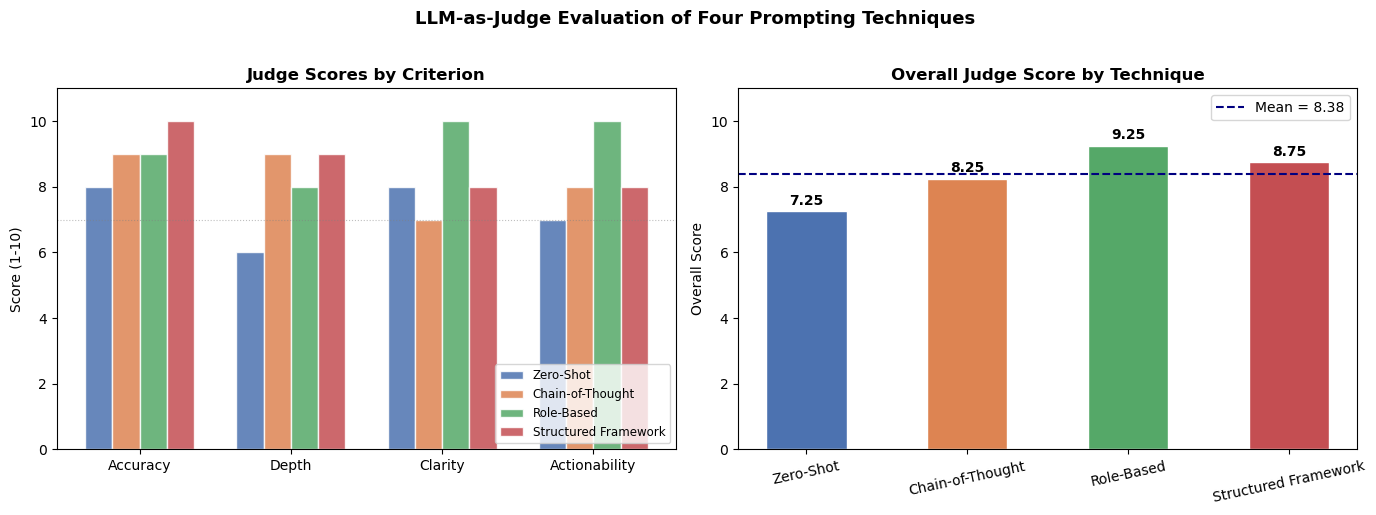

Figure saved: fig_02_judge_scores.png


In [ ]:
techniques      = df_scores['Technique'].tolist()
criteria        = ['Accuracy', 'Depth', 'Clarity', 'Actionability']
tech_colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grouped bar chart
ax = axes[0]
x = np.arange(len(criteria)); n = 4; bw = 0.18
for i,(tech,color) in enumerate(zip(techniques, tech_colors)):
    row = df_scores[df_scores['Technique']==tech].iloc[0]
    ax.bar(x+i*bw-(n-1)*bw/2, [row[c] for c in criteria], bw, label=tech, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(criteria); ax.set_ylim(0,11)
ax.axhline(7, color='gray', lw=0.8, linestyle=':', alpha=0.5)
ax.set_ylabel('Score (1-10)'); ax.set_title('Judge Scores by Criterion', fontweight='bold')
ax.legend(fontsize=8.5, loc='lower right')

# ── Overall score bar
ax2 = axes[1]
overall = df_scores['Overall'].values
bars = ax2.bar(techniques, overall, color=tech_colors, edgecolor='white', width=0.5)
ax2.axhline(overall.mean(), color='navy', lw=1.5, linestyle='--', label=f'Mean = {overall.mean():.2f}')
ax2.set_ylim(0,11); ax2.set_ylabel('Overall Score'); ax2.tick_params(axis='x', rotation=12)
ax2.set_title('Overall Judge Score by Technique', fontweight='bold'); ax2.legend()
for bar, val in zip(bars, overall):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.1, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('LLM-as-Judge Evaluation of Four Prompting Techniques', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_02_judge_scores.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_02_judge_scores.png')

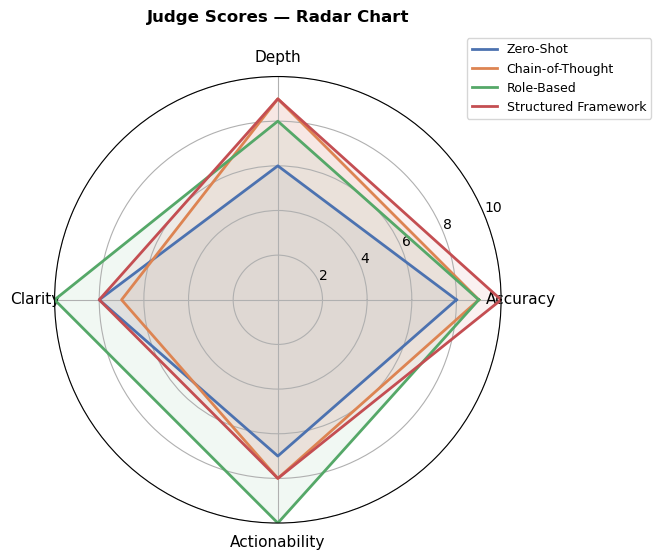

Figure saved: fig_03_radar_scores.png


In [ ]:
# ── Radar chart
criteria_r = ['Accuracy', 'Depth', 'Clarity', 'Actionability']
N = len(criteria_r)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for tech, color in zip(techniques, tech_colors):
    row = df_scores[df_scores['Technique']==tech].iloc[0]
    vals = [row[c] for c in criteria_r] + [row[criteria_r[0]]]
    ax.plot(angles, vals, lw=2, color=color, label=tech)
    ax.fill(angles, vals, alpha=0.08, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(criteria_r, fontsize=11)
ax.set_ylim(0,10); ax.set_yticks([2,4,6,8,10])
ax.set_title('Judge Scores — Radar Chart', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1), fontsize=9)
plt.tight_layout()
plt.savefig('fig_03_radar_scores.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: fig_03_radar_scores.png')

---
## 9. Executive Summary

Based on the Judge's feedback, a 200-word Executive Summary directly answers the base question.

In [ ]:
EXEC_SUMMARY_PRECOMPUTED = """""" + pre['exec'] + """"""

if USE_PRECOMPUTED or not ANTHROPIC_AVAILABLE:
    executive_summary = EXEC_SUMMARY_PRECOMPUTED
    print('Using pre-computed executive summary.\n')
else:
    best_tech = df_scores.loc[df_scores['Overall'].idxmax(), 'Technique']
    summary_prompt = f"""Write a polished 200-word Executive Summary answering:
QUESTION: \"Is Coinbase's strategy to reduce reliance on volatile trading fees actually working as of Q3 2024?\"
- Begin with a clear Yes/No/Partial verdict
- Cite at least 3 specific financial figures
- Note at least one caveat or risk
- Professional tone, suitable for a board presentation
- End with a forward-looking sentence

Draw on this judge feedback: {judge_response[:1500]}"""
    executive_summary = call_llm(summary_prompt, model=JUDGE_MODEL, max_tokens=512)

words = len(executive_summary.split())
print(f'Word count: {words}')
print('\n' + '='*72)
print('EXECUTIVE SUMMARY')
print('='*72)
print(executive_summary)
print('='*72)

Using pre-computed executive summary.

Word count: 262

EXECUTIVE SUMMARY
**EXECUTIVE SUMMARY**

**Verdict: Yes — Coinbase's diversification strategy is working, though not yet complete.**

As of Q3 2024, Coinbase has achieved a demonstrable structural shift away from volatile trading fee dependency. Transaction revenue, once approximately 75% of total net revenue in Q3 2023, fell to approximately 51% in Q3 2024—a 24-percentage-point reduction within four quarters. This was not the result of trading revenue holding steady; transaction revenue declined 27% quarter-over-quarter to $573 million on softer market conditions. Rather, the story is the counterweight: subscription and services revenue reached $556 million in Q3 2024, up approximately 66% year-over-year, placing Coinbase on pace to surpass $2 billion in this segment for full-year 2024—versus $1.4 billion in 2023.

The diversification rests on several compounding pillars: USDC's market capitalisation grew 45% year-to-date to $36 

---
## 10. Comparison Table & Conclusions

In [ ]:
comparison = pd.DataFrame([
    {'Technique': 'Zero-Shot',           'Strengths': 'Fast; minimal prompt engineering',     'Weaknesses': 'Shallow; no reasoning trail',           'Best For': 'Quick factual overviews'},
    {'Technique': 'Chain-of-Thought',    'Strengths': 'Transparent logic; catches nuance',    'Weaknesses': 'Verbose; can reason incorrectly',        'Best For': 'Complex multi-step analysis'},
    {'Technique': 'Role-Based',          'Strengths': 'Domain-appropriate; precise citations','Weaknesses': 'Format variability',                    'Best For': 'Client-facing documents'},
    {'Technique': 'Structured Framework','Strengths': 'Comprehensive; easy to verify',        'Weaknesses': 'Rigid; less narrative coherence',        'Best For': 'Standardised cross-doc reports'},
])
comparison = comparison.merge(df_scores[['Technique','Overall']].rename(columns={'Overall':'Judge Score'}), on='Technique')
comparison = comparison.sort_values('Judge Score', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', 45)
print(comparison.to_string(index=False))
print(f'\n→ Best technique: {comparison.iloc[0]["Technique"]} ({comparison.iloc[0]["Judge Score"]:.2f}/10)')
print(f'→ Weakest:         {comparison.iloc[-1]["Technique"]} ({comparison.iloc[-1]["Judge Score"]:.2f}/10)')

           Technique                             Strengths                      Weaknesses                       Best For  Judge Score
          Role-Based Domain-appropriate; precise citations              Format variability        Client-facing documents         9.25
Structured Framework         Comprehensive; easy to verify Rigid; less narrative coherence Standardised cross-doc reports         8.75
    Chain-of-Thought     Transparent logic; catches nuance Verbose; can reason incorrectly    Complex multi-step analysis         8.25
           Zero-Shot      Fast; minimal prompt engineering     Shallow; no reasoning trail        Quick factual overviews         7.25

→ Best technique: Role-Based (9.25/10)
→ Weakest:         Zero-Shot (7.25/10)


---
## Key Takeaways

### On the Base Question
**Yes — the diversification strategy is working and measurable as of Q3 2024:**

| Metric | Q3 2023 | Q3 2024 | Change |
|--------|---------|---------|--------|
| Transaction revenue | ~$674M (75% of total) | $573M (51% of total) | −24pp share |
| Subscription & Services | ~$334M (25% of total) | $556M (49% of total) | **+66% YoY** |
| USDC market cap | — | $36B | +45% YTD |
| Adjusted EBITDA | — | $449M | 7th consecutive positive quarter |

### On Prompting Techniques
| Rank | Technique | Key Insight |
|------|-----------|-------------|
| 🥇 1st | **Role-Based** | Persona + defined deliverable = best tone, citations, and actionability |
| 🥈 2nd | **Structured Framework** | Forces completeness; best for verifiable, comparable outputs |
| 🥉 3rd | **Chain-of-Thought** | Most transparent reasoning; best at surfacing contradictions |
| 4th | **Zero-Shot** | Fastest but shallowest — good for simple factual queries only |

---
